In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [14]:
fund_master = pd.read_csv("../data/processed/fund_master_clean.csv")
nav_history = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/processed/aum_clean.csv")


In [15]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum.shape)

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)


In [16]:
fund_master.head()
nav_history.head()
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [17]:
nav_history.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [18]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

chart -1 NAV Trend

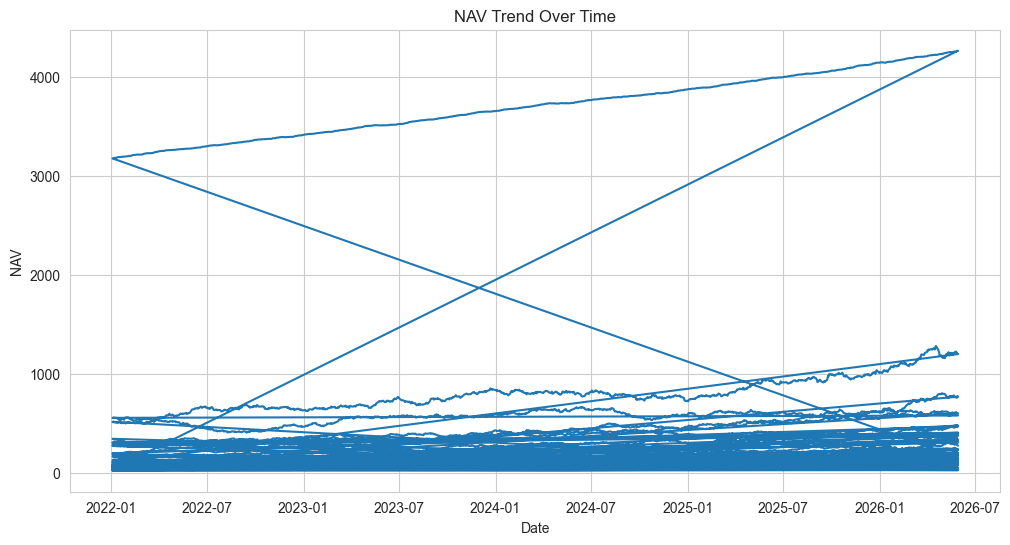

In [19]:
plt.figure(figsize=(12,6))

plt.plot(nav_history['date'], nav_history['nav'])

plt.title('NAV Trend Over Time')
plt.xlabel('Date')
plt.ylabel('NAV')

plt.show()

Insight:
The NAV trend shows how the mutual fund value changes over time.
An upward trend indicates long-term growth in fund value.

In [20]:
aum.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

In [21]:
aum['date'] = pd.to_datetime(aum['date'])

In [22]:
latest_aum = (
    aum.sort_values('date')
       .groupby('fund_house')
       .tail(1)
)

chart-2 AUM Analysis

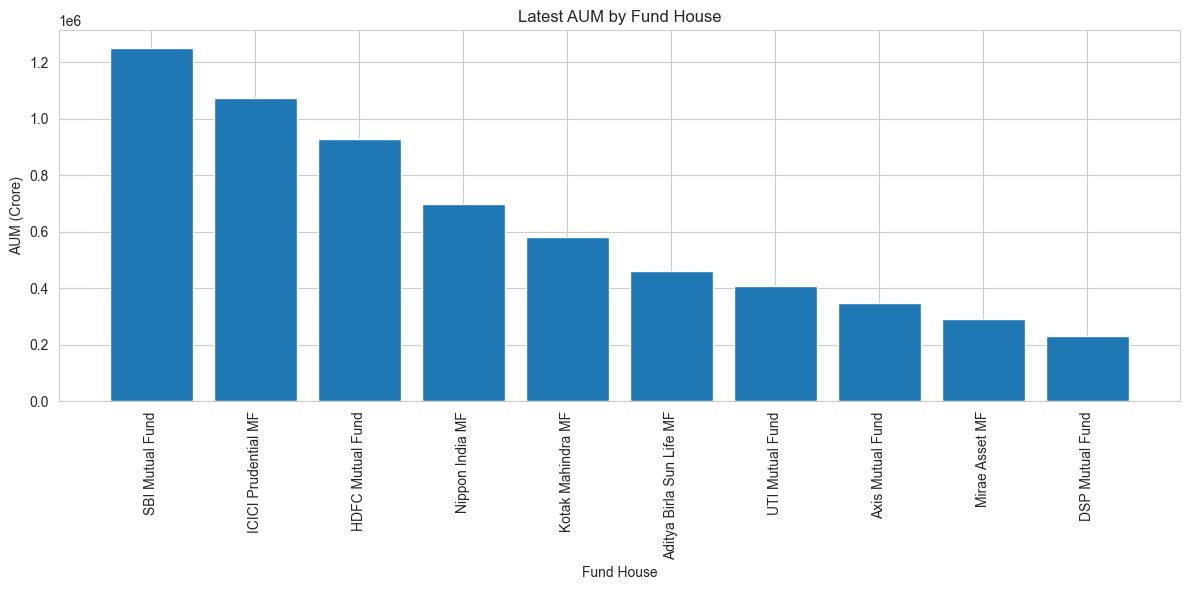

In [23]:
plt.figure(figsize=(12,6))

latest_aum = latest_aum.sort_values(
    'aum_crore',
    ascending=False
)

plt.bar(
    latest_aum['fund_house'],
    latest_aum['aum_crore']
)

plt.xticks(rotation=90)
plt.title('Latest AUM by Fund House')
plt.xlabel('Fund House')
plt.ylabel('AUM (Crore)')

plt.tight_layout()
plt.show()

Insight:
AUM (Assets Under Management) helps identify the largest mutual fund houses.
Fund houses with higher AUM generally manage a larger investor base and asset portfolio.


In [24]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

In [25]:
sip['month'] = pd.to_datetime(sip['month'])

chart -3 SIP Inflow Trend

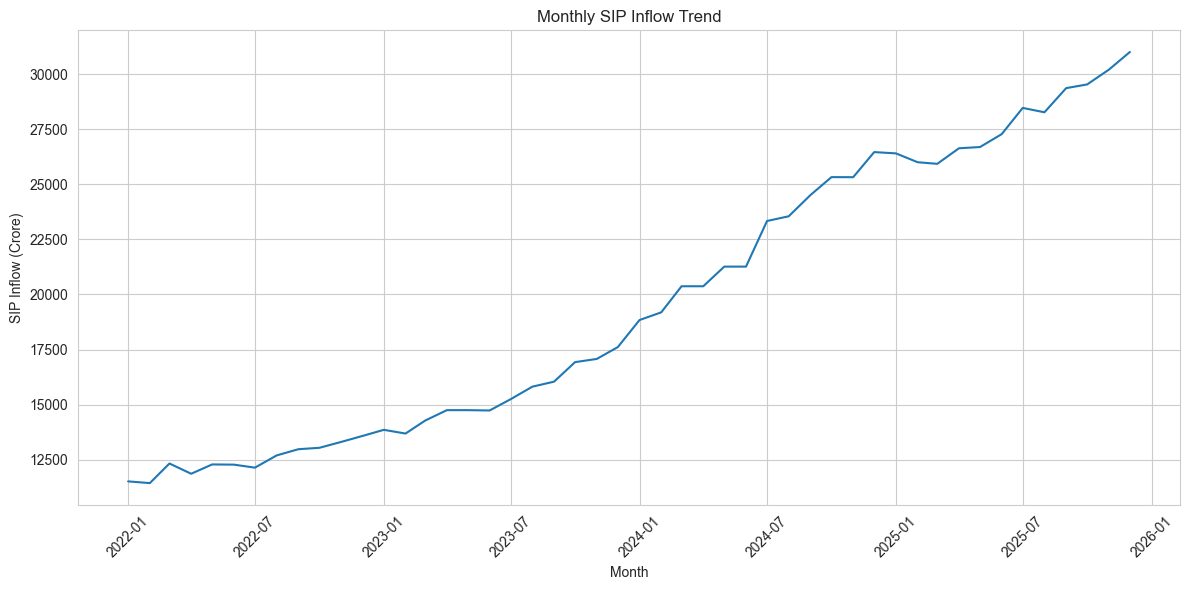

In [26]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore']
)

plt.title('Monthly SIP Inflow Trend')
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Crore)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insight:
Monthly SIP inflows indicate the level of retail investor participation.
A rising trend suggests increasing investor confidence and systematic investing behavior.


chart-4 Active SIP Accounts Trend

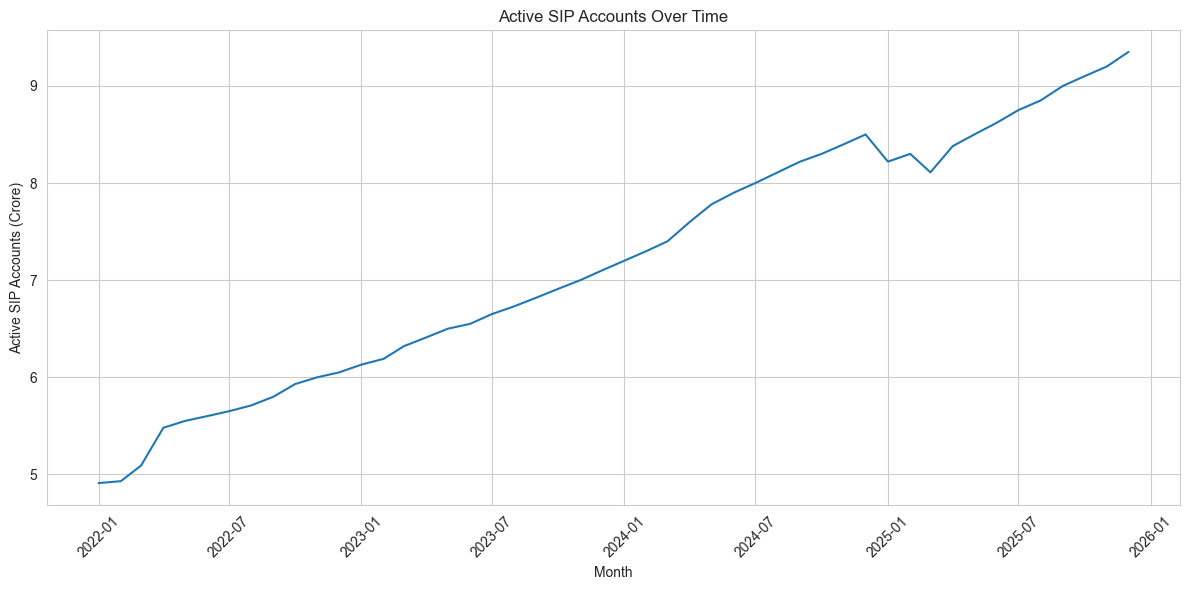

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['active_sip_accounts_crore']
)

plt.title('Active SIP Accounts Over Time')
plt.xlabel('Month')
plt.ylabel('Active SIP Accounts (Crore)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insight:
Growth in active SIP accounts reflects expanding mutual fund adoption among investors.

chart-5 YoY Growth Analysis

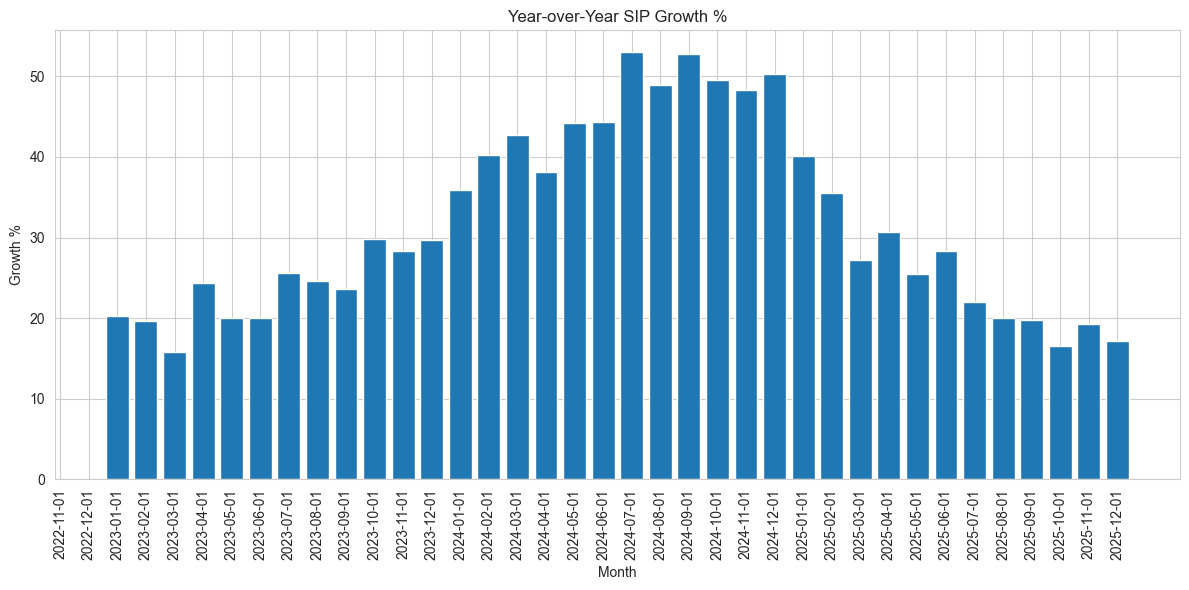

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    sip['month'].astype(str),
    sip['yoy_growth_pct']
)

plt.title('Year-over-Year SIP Growth %')
plt.xlabel('Month')
plt.ylabel('Growth %')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

Insight:
YoY growth highlights how rapidly SIP investments are increasing compared to the previous year.

In [29]:
fund_master.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')